# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [32]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [33]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [34]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [35]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [36]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

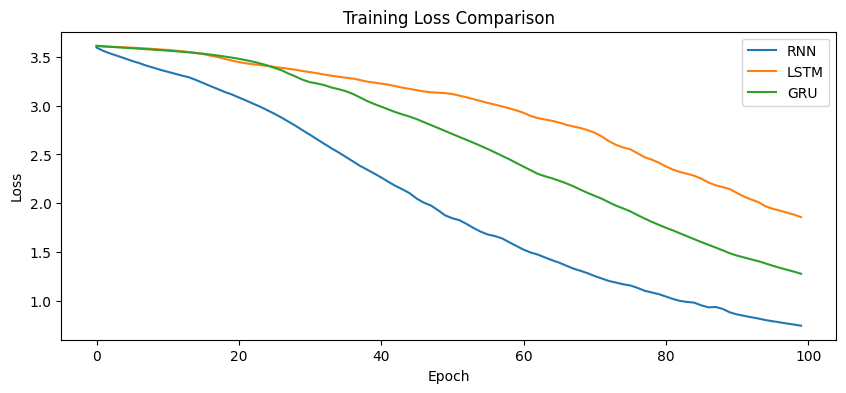

In [37]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [38]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [39]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is transforming generate intelligence intelligence
GRU : deep learning is transforming artificial intelligence intelligence


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

## Task 1 & 2 — Own corpus + larger embedding

In [40]:
my_corpus = """
astronauts train for years before their first mission
rockets need enormous amounts of fuel to escape gravity
mars missions face challenges like radiation and isolation
satellites orbiting earth help us track weather patterns
space agencies are now building reusable rocket systems
future colonies may depend on solar power and recycled water
"""
print(my_corpus.strip())

astronauts train for years before their first mission
rockets need enormous amounts of fuel to escape gravity
mars missions face challenges like radiation and isolation
satellites orbiting earth help us track weather patterns
space agencies are now building reusable rocket systems
future colonies may depend on solar power and recycled water


In [41]:
arp_tokenizer = Tokenizer()
arp_tokenizer.fit_on_texts([my_corpus])
vocab_size = len(arp_tokenizer.word_index) + 1
print(f"vocab size: {vocab_size}")

def build_ngram_sequences(text, tok):
    sequences = []
    for line in text.strip().split("\n"):
        encoded = tok.texts_to_sequences([line])[0]
        sequences += [encoded[:i] for i in range(2, len(encoded) + 1)]
    return sequences

ngram_seqs = build_ngram_sequences(my_corpus, arp_tokenizer)
seq_len = max(len(s) for s in ngram_seqs)
ngram_seqs = pad_sequences(ngram_seqs, maxlen=seq_len, padding="pre")

X_train, y_train = ngram_seqs[:, :-1], ngram_seqs[:, -1]
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

vocab size: 51
X_train: (45, 9), y_train: (45,)


## Task 4 — Bigger hidden layers (128 units)

In [42]:
EMB_DIM = 96
UNITS = 128

def make_model(layer_type):
    m = Sequential()
    m.add(Embedding(vocab_size, EMB_DIM, input_length=seq_len - 1))
    m.add(layer_type(UNITS))
    m.add(Dense(vocab_size, activation="softmax"))
    m.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return m

simple_rnn_net = make_model(SimpleRNN)
lstm_net = make_model(LSTM)
gru_net = make_model(GRU)
print("built 3 models with embedding dim", EMB_DIM, "and", UNITS, "hidden units each")

built 3 models with embedding dim 96 and 128 hidden units each


## Task 3 — 200 training epochs

In [43]:
NUM_EPOCHS = 200
histories = {}
for name, net in [("SimpleRNN", simple_rnn_net), ("LSTM", lstm_net), ("GRU", gru_net)]:
    print(f"training {name}...")
    histories[name] = net.fit(X_train, y_train, epochs=NUM_EPOCHS, verbose=0)
    print(f"{name} done")

training SimpleRNN...
SimpleRNN done
training LSTM...
LSTM done
training GRU...
GRU done


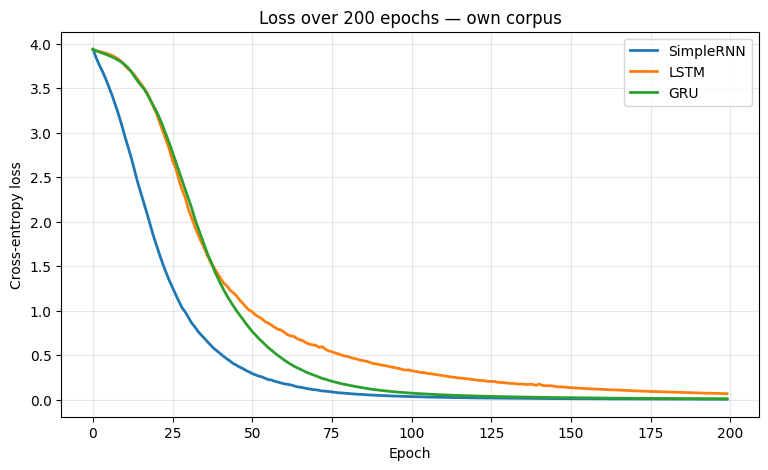

In [44]:
plt.figure(figsize=(9, 5))
for name, hist in histories.items():
    plt.plot(hist.history["loss"], label=name, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title(f"Loss over {NUM_EPOCHS} epochs — own corpus")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Task 5 — Generate 10 words per model

In [45]:
def predict_next_words(model, seed, tok, pad_len, count=10):
    text = seed
    words_left = count
    while words_left > 0:
        encoded = tok.texts_to_sequences([text])[0]
        encoded = pad_sequences([encoded], maxlen=pad_len - 1, padding="pre")
        next_id = np.argmax(model.predict(encoded, verbose=0), axis=-1)[0]
        next_word = next((w for w, idx in tok.word_index.items() if idx == next_id), "")
        text = f"{text} {next_word}"
        words_left -= 1
    return text

for name, net in [("SimpleRNN", simple_rnn_net), ("LSTM", lstm_net), ("GRU", gru_net)]:
    print(f"{name}: {predict_next_words(net, 'space missions', arp_tokenizer, seq_len)}")

SimpleRNN: space missions are now building reusable rocket systems gravity their fuel and
LSTM: space missions face challenges challenges reusable and and isolation water water water
GRU: space missions face challenges like radiation and isolation isolation water water water


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**